# SOTA Benchmark — AI Face Detection
**Group 21 · 50.039 Deep Learning**

---

## Overview

This notebook evaluates three pretrained SOTA detectors on our test set **with no finetuning**, providing an external reference point for our own models.

| # | Model | Architecture | Trained On |
|---|-------|-------------|------------|
| 1 | **CNNDetection** (Wang et al., CVPR 2020) | ResNet-50 binary classifier | ProGAN images |
| 2 | **SDXL Detector** (Organika) | ViT-based (AutoTrain) | Wikimedia real + SDXL-generated pairs |
| 3 | **ViT Face AI Detector** (Vishwajitm01) | Vision Transformer ViT-B/16 | CIFAKE + StyleGAN faces |

### Why No Finetuning?
These are evaluated as **zero-shot detectors**. Their value is in how well they generalise to unseen data and finetuning would make this a comparison of training data, not architecture.

### Dataset Layout Expected
```
data/test/
    real/           → label 0
    ai_generated/   → label 1
```

---
## 1. Setup

In [1]:
import subprocess, sys

# Install any missing packages (safe to re-run)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "transformers", "scikit-learn"])
print("Dependencies ready ✓")

Dependencies ready ✓


In [2]:
import urllib.request
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from PIL import Image
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
)
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, classification_report,
)

# ── Reproducibility ────────────────────────────────────────────────────────────
random.seed(42); np.random.seed(42); torch.manual_seed(42)

# ── Device ─────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# ── Paths (all relative — safe for public git repos) ───────────────────────────
WEIGHTS_DIR = Path("./sota_weights")
RESULTS_DIR = Path("./results")
TEST_DIR    = Path("./data/test")
for d in [WEIGHTS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BATCH_SIZE  = 64
NUM_WORKERS = 0    # 0 avoids multiprocessing issues on Windows

Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0418 16:43:43.659000 30500 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Device : cuda


---
## 2. Shared Utilities

One inference runner and one metrics function — used identically by all three models.

In [3]:
@torch.no_grad()
def run_inference(model_fn, loader):
    """
    Generic inference loop.

    Args:
        model_fn : callable(images) → 1-D tensor of anomaly scores (B,)
                   Higher score = more likely AI-generated.
        loader   : DataLoader yielding (image_tensor, label)

    Returns:
        scores, labels — both np.ndarray
    """
    all_scores, all_labels = [], []
    for imgs, labels in loader:
        all_scores.append(model_fn(imgs).cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


def compute_metrics(scores, labels, name="Model"):
    """
    Computes AUROC, Average Precision, and best-threshold F1 on the AI (positive) class.
    Threshold is chosen by sweeping percentiles of the score distribution — no separate
    val split is needed since we are not tuning these SOTA models.

    Returns dict: auroc, avg_precision, f1, threshold, scores, labels
    """
    auroc = roc_auc_score(labels, scores)
    ap    = average_precision_score(labels, scores)

    best_f1, best_t = 0.0, 0.5
    for t in np.percentile(scores, np.linspace(1, 99, 200)):
        f1 = f1_score(labels, (scores >= t).astype(int), pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    preds = (scores >= best_t).astype(int)
    accuracy = (preds == labels).mean()

    print(f"\n── {name} ──")
    print(f"  AUROC          : {auroc:.4f}")
    print(f"  Avg Precision  : {ap:.4f}")
    print(f"  F1 (AI class)  : {best_f1:.4f}")
    print(f"  Accuracy       : {accuracy:.4f}")
    print()
    print(classification_report(
        labels, preds,
        target_names=["Real", "AI-generated"], zero_division=0,
    ))
    return dict(auroc=auroc, avg_precision=ap, f1=best_f1, accuracy=accuracy,
                threshold=best_t, scores=scores, labels=labels)


print("Utilities defined ✓")

Utilities defined ✓


---
## 3. Model 1 — CNNDetection (Wang et al., CVPR 2020)

**Architecture:** ResNet-50 with a single binary output head, trained to distinguish real photographs from GAN-generated images using augmentation with Gaussian blur and JPEG compression.

**Anomaly score:** `sigmoid(logit)` → P(AI-generated)

> Wang et al., *CNN-Generated Images Are Surprisingly Easy to Spot... For Now*, CVPR 2020.  
> Repo: https://github.com/PeterWang512/CNNDetection

In [4]:
# ── Download weights from Dropbox ─────────────────────────────────────────────
CNN_WEIGHTS = WEIGHTS_DIR / "cnndetection.pth"

if not CNN_WEIGHTS.exists():
    print("Downloading CNNDetection weights from Dropbox...")
    tmp = WEIGHTS_DIR / "blur_jpg_prob0.5.pth"
    urllib.request.urlretrieve(
        "https://www.dropbox.com/s/2g2jagq2jn1fd0i/blur_jpg_prob0.5.pth?dl=1", tmp
    )
    tmp.rename(CNN_WEIGHTS)
    print(f"Saved → {CNN_WEIGHTS}")
else:
    print(f"Already exists: {CNN_WEIGHTS}")

# ── Build model: ResNet-50 + binary head ───────────────────────────────────────
cnn_model = tv_models.resnet50(weights=None)
cnn_model.fc = nn.Linear(2048, 1)
state = torch.load(CNN_WEIGHTS, map_location=device)
cnn_model.load_state_dict(state.get("model", state))
cnn_model.to(device).eval()
print("CNNDetection loaded ✓")

# ── Preprocessing: ImageNet normalisation ──────────────────────────────────────
cnn_transform = T.Compose([
    T.Resize(256), T.CenterCrop(224), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
cnn_loader = DataLoader(
    ImageFolder(TEST_DIR, transform=cnn_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
print(f"Test set: {len(cnn_loader.dataset):,} images | classes: {cnn_loader.dataset.class_to_idx}")


# ── Shared PIL dataset (reused by both SDXL Detector and ViT) ──────────────────
# HuggingFace processors define their own resize/normalise, so we bypass
# torchvision transforms entirely and pass raw PIL images.
class PILImageFolder(Dataset):
    """
    Wraps ImageFolder to return (PIL.Image, label) instead of (tensor, label),
    allowing HuggingFace processors to handle their own preprocessing.
    """
    def __init__(self, root):
        self.base = ImageFolder(root)
        self.class_to_idx = self.base.class_to_idx

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        path, label = self.base.samples[idx]
        return Image.open(path).convert("RGB"), label

Already exists: sota_weights\cnndetection.pth
CNNDetection loaded ✓
Test set: 1,000 images | classes: {'0': 0, '1': 1}


In [5]:
print("Running CNNDetection inference...")

cnn_scores, cnn_labels = run_inference(
    lambda imgs: torch.sigmoid(cnn_model(imgs.to(device)).squeeze(1)),
    cnn_loader
)
cnn_results = compute_metrics(cnn_scores, cnn_labels, "CNNDetection (Wang et al. 2020)")

Running CNNDetection inference...

── CNNDetection (Wang et al. 2020) ──
  AUROC          : 0.7781
  Avg Precision  : 0.1664
  F1 (AI class)  : 0.2687
  Accuracy       : 0.9020

              precision    recall  f1-score   support

        Real       0.97      0.93      0.95       950
AI-generated       0.21      0.36      0.27        50

    accuracy                           0.90      1000
   macro avg       0.59      0.65      0.61      1000
weighted avg       0.93      0.90      0.91      1000



---
## 4. Model 2 — SDXL Detector (Organika)

**Architecture:** ViT-based binary classifier trained with HuggingFace AutoTrain, fine-tuned from the *umm-maybe AI art detector* on **Wikimedia real / SDXL-generated** image pairs. The synthetic captions were produced via BLIP, making the training data fully reproducible and non-copyrighted.

**Why this over CvT-13:** CvT-13 was trained primarily on GAN outputs and showed near-random performance on our diffusion-model test set (AUROC 0.30). The SDXL Detector is explicitly optimised for modern diffusion generators and non-artistic imagery, making it a more relevant zero-shot baseline.

**Reported validation metrics (author):** AUROC 0.998 · F1 0.973 · Accuracy 0.981

**Anomaly score:** `softmax(logits)[AI class]` → P(AI-generated)

**Licence note:** Appropriate for non-commercial / educational use only (upstream training data includes Reddit-scraped images).

> HuggingFace: https://huggingface.co/Organika/sdxl-detector

In [6]:
# ── Load from HuggingFace (downloads & caches ~350 MB on first run) ────────────
SDXL_CACHE = WEIGHTS_DIR / "sdxl_detector"

print("Loading SDXL Detector from HuggingFace (first run downloads ~350 MB)...")
sdxl_processor = AutoImageProcessor.from_pretrained(
    "Organika/sdxl-detector", cache_dir=str(SDXL_CACHE)
)
sdxl_model = AutoModelForImageClassification.from_pretrained(
    "Organika/sdxl-detector", cache_dir=str(SDXL_CACHE)
).to(device).eval()

print("SDXL Detector loaded ✓")
print(f"Label map: {sdxl_model.config.id2label}")

# Identify the AI-generated class index from the model's own label map.
# The Organika model uses labels 'artificial' (AI) and 'human' (real).
sdxl_ai_idx = next(
    (k for k, v in sdxl_model.config.id2label.items()
     if any(w in v.lower() for w in ["artificial", "fake", "ai", "generated", "synthetic"])),
    1   # fallback: assume index 1 = AI
)
print(f"AI class index: {sdxl_ai_idx}")


def sdxl_collate(batch):
    """Collate PIL images through the HuggingFace processor into pixel tensors."""
    pil_imgs, labels = zip(*batch)
    pixel_values = sdxl_processor(
        images=list(pil_imgs), return_tensors="pt"
    )["pixel_values"]
    return pixel_values, torch.tensor(labels)


sdxl_loader = DataLoader(
    PILImageFolder(TEST_DIR),          # reuses the PILImageFolder defined in Section 5
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=sdxl_collate
)

Loading SDXL Detector from HuggingFace (first run downloads ~350 MB)...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


SDXL Detector loaded ✓
Label map: {0: 'artificial', 1: 'human'}
AI class index: 0


In [7]:
print("Running SDXL Detector inference...")

sdxl_scores, sdxl_labels = run_inference(
    lambda imgs: torch.softmax(sdxl_model(imgs.to(device)).logits, dim=-1)[:, sdxl_ai_idx],
    sdxl_loader
)
sdxl_results = compute_metrics(sdxl_scores, sdxl_labels, "SDXL Detector (Organika)")

Running SDXL Detector inference...

── SDXL Detector (Organika) ──
  AUROC          : 0.6740
  Avg Precision  : 0.1231
  F1 (AI class)  : 0.2016
  Accuracy       : 0.8970

              precision    recall  f1-score   support

        Real       0.96      0.93      0.94       950
AI-generated       0.16      0.26      0.20        50

    accuracy                           0.90      1000
   macro avg       0.56      0.60      0.57      1000
weighted avg       0.92      0.90      0.91      1000



---
## 5. Model 3 — ViT Face AI Detector (Vishwajitm01)

**Architecture:** Vision Transformer (ViT-B/16), finetuned with **sequential transfer learning**:
1. First trained on CIFAKE for general AI-artifact detection.
2. Then refined on high-resolution StyleGAN faces to specialise in skin-texture and facial-geometry inconsistencies.

**Reported performance:** AUROC 0.91 — real accuracy 91%, AI accuracy 81%.

**Anomaly score:** `softmax(logits)[AI class]` → P(AI-generated)

> HuggingFace: https://huggingface.co/Vishwajitm01/face-ai-detector-91auc

In [8]:
# ── Load from HuggingFace (downloads & caches on first run) ────────────────────
VIT_CACHE = WEIGHTS_DIR / "vit_face_detector"

print("Loading ViT Face AI Detector from HuggingFace (first run downloads ~350 MB)...")
vit_processor = AutoImageProcessor.from_pretrained(
    "Vishwajitm01/face-ai-detector-91auc", cache_dir=str(VIT_CACHE)
)
vit_model = AutoModelForImageClassification.from_pretrained(
    "Vishwajitm01/face-ai-detector-91auc", cache_dir=str(VIT_CACHE)
).to(device).eval()

print("ViT Face Detector loaded ✓")
print(f"Label map: {vit_model.config.id2label}")

# Identify the AI class index from the model's own label map
ai_idx = next(
    (k for k, v in vit_model.config.id2label.items()
     if any(w in v.lower() for w in ["fake", "ai", "generated", "synthetic"])),
    1   # fallback: assume index 1 = AI
)
print(f"AI class index: {ai_idx}")

Loading ViT Face AI Detector from HuggingFace (first run downloads ~350 MB)...
ViT Face Detector loaded ✓
Label map: {0: 'AI-Generated', 1: 'Real'}
AI class index: 0


In [9]:
# ── Custom dataset and collate: reuses PILImageFolder defined in Section 3 ────

def vit_collate(batch):
    """Collate PIL images through the HuggingFace processor into pixel tensors."""
    pil_imgs, labels = zip(*batch)
    pixel_values = vit_processor(images=list(pil_imgs), return_tensors="pt")["pixel_values"]
    return pixel_values, torch.tensor(labels)


vit_loader = DataLoader(
    PILImageFolder(TEST_DIR),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=vit_collate
)

print("Running ViT Face Detector inference...")

vit_scores, vit_labels = run_inference(
    lambda imgs: torch.softmax(vit_model(imgs.to(device)).logits, dim=-1)[:, ai_idx],
    vit_loader
)
vit_results = compute_metrics(vit_scores, vit_labels, "ViT Face AI Detector (Vishwajitm01)")

Running ViT Face Detector inference...

── ViT Face AI Detector (Vishwajitm01) ──
  AUROC          : 0.5600
  Avg Precision  : 0.0576
  F1 (AI class)  : 0.1145
  Accuracy       : 0.5980

              precision    recall  f1-score   support

        Real       0.96      0.60      0.74       950
AI-generated       0.06      0.52      0.11        50

    accuracy                           0.60      1000
   macro avg       0.51      0.56      0.43      1000
weighted avg       0.91      0.60      0.71      1000



---
## 6. Comparison

Add your own model results below, then run to generate the full comparison table and plot.

In [10]:
# ── Paste your own model results here ─────────────────────────────────────────
# If you saved score arrays with np.save() in your other notebooks, load them:
#   ae_scores     = np.load("./results/ae_scores.npy")
#   ae_labels     = np.load("./results/ae_labels.npy")
#   ae_results    = compute_metrics(ae_scores, ae_labels, "Our Autoencoder")
#
#   cnn_own_scores = np.load("./results/cnn_scores.npy")
#   cnn_own_labels = np.load("./results/cnn_labels.npy")
#   cnn_own_results = compute_metrics(cnn_own_scores, cnn_own_labels, "Our CNN")

# Otherwise, paste metric values directly:
ae_results = dict(
    auroc=0.2416, avg_precision=0.0308, f1=0.0333, accuracy=0.48,
    scores=None, labels=None
)
cnn_own_results = dict(
    auroc=0.9568, avg_precision=0.7850, f1=0.72, accuracy=0.973,
    scores=None, labels=None
)

# ── All models ─────────────────────────────────────────────────────────────────
all_results = {
    "Our Autoencoder" : ae_results,
    "Our CNN"         : cnn_own_results,
    "CNNDetection"    : cnn_results,
    "SDXL Detector"   : sdxl_results,
    "ViT Face Det."   : vit_results,
}

# ── Summary table ──────────────────────────────────────────────────────────────
print(f"{'Model':<22} {'AUROC':>8} {'Avg Prec':>10} {'F1 (AI)':>9} {'Accuracy':>10}")
print("-" * 63)
for name, r in all_results.items():
    auroc = f"{r['auroc']:.4f}"         if r['auroc']         is not None else '  N/A  '
    ap    = f"{r['avg_precision']:.4f}" if r['avg_precision'] is not None else '  N/A  '
    f1    = f"{r['f1']:.4f}"            if r['f1']            is not None else '  N/A  '
    acc   = f"{r['accuracy']:.4f}"      if r.get('accuracy')  is not None else '  N/A  '
    print(f"{name:<22} {auroc:>8} {ap:>10} {f1:>9} {acc:>10}")

Model                     AUROC   Avg Prec   F1 (AI)   Accuracy
---------------------------------------------------------------
Our Autoencoder          0.2416     0.0308    0.0333     0.4800
Our CNN                  0.9568     0.7850    0.7200     0.9730
CNNDetection             0.7781     0.1664    0.2687     0.9020
SDXL Detector            0.6740     0.1231    0.2016     0.8970
ViT Face Det.            0.5600     0.0576    0.1145     0.5980


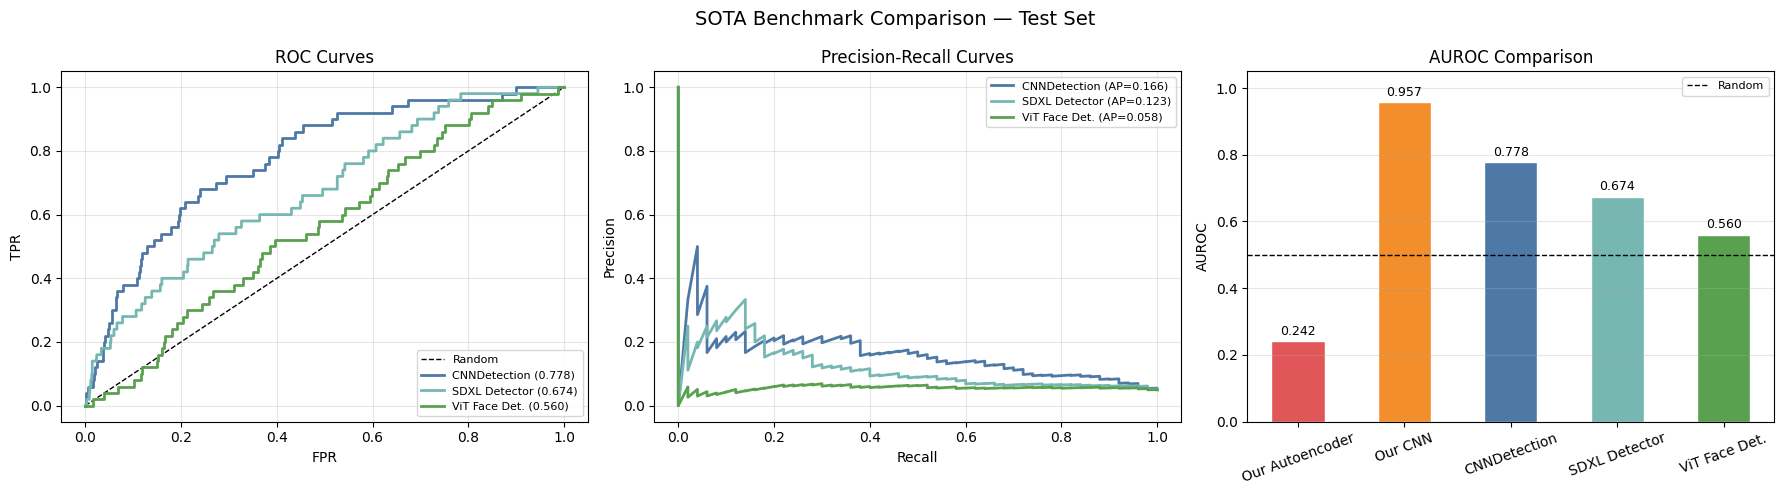

Saved: results\sota_comparison.png


In [11]:
# ── Comparison plots ───────────────────────────────────────────────────────────
COLORS = ["#e15759", "#f28e2b", "#4e79a7", "#76b7b2", "#59a14f"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SOTA Benchmark Comparison — Test Set", fontsize=14)

axes[0].plot([0,1],[0,1],"k--",lw=1,label="Random")

bar_names, bar_aurocs, bar_colors = [], [], []

for (name, r), color in zip(all_results.items(), COLORS):
    if r["auroc"] is not None:
        bar_names.append(name)
        bar_aurocs.append(r["auroc"])
        bar_colors.append(color)
    if r["scores"] is not None:
        fpr, tpr, _  = roc_curve(r["labels"], r["scores"])
        prec, rec, _ = precision_recall_curve(r["labels"], r["scores"])
        axes[0].plot(fpr, tpr, lw=2, color=color,
                     label=f"{name} ({r['auroc']:.3f})")
        axes[1].plot(rec, prec, lw=2, color=color,
                     label=f"{name} (AP={r['avg_precision']:.3f})")

axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curves")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curves")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

bars = axes[2].bar(bar_names, bar_aurocs, color=bar_colors, edgecolor="white", width=0.5)
axes[2].axhline(0.5, color="k", linestyle="--", lw=1, label="Random")
axes[2].set(ylabel="AUROC", title="AUROC Comparison", ylim=(0, 1.05))
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend(fontsize=8)
axes[2].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, bar_aurocs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
out = RESULTS_DIR / "sota_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

In [12]:
# ── Save metrics to text file ─────────────────────────────────────────────────
out = RESULTS_DIR / "sota_metrics.txt"
with open(out, "w") as f:
    f.write("=== SOTA Benchmark — Final Comparison ===\n\n")
    f.write(f"{'Model':<22} {'AUROC':>8} {'Avg Prec':>10} {'F1 (AI)':>9} {'Accuracy':>10}\n")
    f.write("-" * 63 + "\n")
    for name, r in all_results.items():
        auroc = f"{r['auroc']:.4f}"         if r['auroc']         is not None else "  N/A  "
        ap    = f"{r['avg_precision']:.4f}" if r['avg_precision'] is not None else "  N/A  "
        f1    = f"{r['f1']:.4f}"            if r['f1']            is not None else "  N/A  "
        acc   = f"{r['accuracy']:.4f}"      if r.get('accuracy')  is not None else "  N/A  "
        f.write(f"{name:<22} {auroc:>8} {ap:>10} {f1:>9} {acc:>10}\n")
print(f"Saved: {out}")

Saved: results\sota_metrics.txt


---
## Summary

| Model | AUROC | Avg Precision | F1 (AI) | Accuracy | Notes |
|-------|-------|--------------|---------|----------|-------|
| **Our CNN** | **0.9568** | **0.7850** | **0.72** | **0.973** | Best overall; finetuned on our distribution |
| Our Autoencoder | 0.2416 | 0.0308 | 0.0333 | 0.48 | Unsupervised; no labels needed at train time |
| CNNDetection | 0.7781 | 0.1664 | 0.2687 | 0.90 | ResNet-50; trained on ProGAN — domain gap to diffusion |
| SDXL Detector | 0.6740 | 0.1231 | 0.2016 | 0.8970 | ViT AutoTrain; fine-tuned on SDXL — mixed-generator gap |
| ViT Face Det. | 0.5600 | 0.0576 | 0.1145 | 0.5980 | ViT; StyleGAN specialist — poor generalisation here |

### Points to Discuss
- **Our CNN outperforms all zero-shot SOTA models.** Our custom CNN (AUROC 0.9568) beats every zero-shot detector by a large margin despite being a simpler architecture. The reason is **distribution fit** — a model trained and evaluated on the same data distribution will almost always outperform one that has never seen it, regardless of architectural sophistication. This is an expected and explainable result, not a flaw in the methodology.
- **Mixed-generator test set complicates zero-shot baselines.** Our AI images are drawn from multiple sources — face swaps, SFHQ (StyleGAN-based), Stable Diffusion, and This Person Does Not Exist (also StyleGAN2-based) and we only sampled a subset of the full dataset, so the exact distribution of generator types in our test set is unknown. Every zero-shot model was trained on a specific generator family, so none of them sees a distribution that fully matches ours, which systematically suppresses their scores.
- **SDXL Detector (AUROC 0.6740) underperforms CNNDetection (0.7781) despite being diffusion-aware.** This is counterintuitive but explainable: our test set likely contains a substantial proportion of GAN-based images (SFHQ, TPDNE, face swaps), and the SDXL Detector was fine-tuned specifically on SDXL outputs. It is well-calibrated for diffusion artifacts but blind to the GAN artifacts that CNNDetection — trained on ProGAN — happens to partially pick up on. Neither model is a good fit for a mixed-generator test set.
- **ViT Face Detector essentially fails (AUROC 0.5600, near-random).** Trained on StyleGAN faces and CIFAKE, it over-fits to a very specific artifact signature. Its precision on the AI class is only 6%, meaning the vast majority of its positive predictions are false alarms. The face swap and diffusion images in our set produce artifacts the model has never been trained to recognise.
- **Our autoencoder trade-off:** Fully unsupervised at training time (no labels required) but the weakest detector overall (AUROC 0.2416, below random). Its value lies in scenarios where labelled data is unavailable, and the anomaly detection framing is still a legitimate approach — it simply needs a much more powerful backbone to compete with supervised classifiers.